In [62]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from itertools import product 
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

df = pd.read_csv("df_hmm_var.csv", parse_dates=["date"])
df["rvar_lag1"] = df["realized_variance"].shift(1)
df["rvar_lag2"] = df["realized_variance"].shift(2)
df["rvar_lag3"] = df["realized_variance"].shift(3)
df_clean = df.dropna(subset=['hmm_regime', 'hmm_prob_high']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nRegime distribution:")
print(df['hmm_regime'].value_counts().sort_index())

Dataset shape: (3489, 52)

Regime distribution:
hmm_regime
0.0    1975
1.0    1149
Name: count, dtype: int64


In [63]:
svr_features = [
    "log_return",
    "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg",
    "rvar_7",
    "rvar_30",
    "rvar_lag1",
    "rvar_lag2",
    "rvar_lag3",
    "hmm_prob_high" #,
    #"hmm_prob_high_lag1",
    #"hmm_prob_high_lag2",
    #"hmm_prob_high_roll5"
]
print(f"\nTotal SVR features: {len(svr_features)}")


Total SVR features: 34


In [64]:
# Define clipping 
# floor: rolling mean 5 for predicted variance
#df_clean["var_floor_5"] = df_clean["target_var"].shift(1).rolling(5, min_periods=5).mean()
# global upper bound
upper_bound = df_clean["target_var"].quantile(0.995)

#def clip_variance_pred(pred, floor_val, upper_bound):
#    if pd.isna(floor_val):
#        floor_val = 1e-8
#    else:
#        floor_val = max(1e-8, floor_val)
#    return np.clip(pred, floor_val, upper_bound)

In [65]:
# 60/25/15 split
total_len = len(df_clean)
train_size = int(total_len * 0.60)
val_size = int(total_len * 0.25)

train_end = train_size
val_start = train_size
val_end = train_size + val_size
test_start = val_end

print(f"Train: {0:4d} to {train_end:4d} ({train_size:4d} days) | {df_clean['date'].iloc[0]} to {df_clean['date'].iloc[train_end-1]}")
print(f"Val:   {val_start:4d} to {val_end:4d} ({val_size:4d} days) | {df_clean['date'].iloc[val_start]} to {df_clean['date'].iloc[val_end-1]}")
print(f"Test:  {test_start:4d} to {total_len:4d} ({total_len - test_start:4d} days) | {df_clean['date'].iloc[test_start]} to {df_clean['date'].iloc[-1]}")

window_size = 365

Train:    0 to 1874 (1874 days) | 2017-07-13 00:00:00 to 2022-08-29 00:00:00
Val:   1874 to 2655 ( 781 days) | 2022-08-30 00:00:00 to 2024-10-18 00:00:00
Test:  2655 to 3124 ( 469 days) | 2024-10-19 00:00:00 to 2026-01-30 00:00:00


In [ ]:
# Grid search for C and epsilon
C_values = [0.1, 1.0, 10.0, 100.0]
epsilon_values = [0.001, 0.01, 0.1]

val_sample_indices = range(val_start, val_end, 5)
valid_indices = [i for i in val_sample_indices if i >= window_size]
grid_results = []
total_configs = len(C_values) * len(epsilon_values)

print(f"Testing {total_configs} configurations on {len(valid_indices)} samples...")
print(f"Total features: {len(svr_features)}")
print(f"Window size: {window_size} days")

config_num = 0

for C, epsilon in product(C_values, epsilon_values):
    config_num += 1
    
    preds = []
    actuals = []
    
    for i in valid_indices:
        train_X = df_clean.iloc[i - window_size : i][svr_features].values
        train_y = df_clean.iloc[i - window_size : i]['target_var'].values
        
        test_X = df_clean.iloc[i:i+1][svr_features].values
        target_val = df_clean.iloc[i]['target_var']
        
        try:
            # Scale features AND target
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            
            train_X_scaled = scaler_X.fit_transform(train_X)
            train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
            test_X_scaled = scaler_X.transform(test_X)
            
            # Fit SVR with current hyperparameters
            model = SVR(kernel='linear', C=C, epsilon=epsilon, max_iter=1000)  # Add max_iter
            model.fit(train_X_scaled, train_y_scaled)
            
            # Predict and inverse transform
            pred_scaled = model.predict(test_X_scaled)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            #clip
            pred_scaled = model.predict(test_X_scaled)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            pred = np.clip(pred, 1e-7, upper_bound)
            
            preds.append(pred)
            actuals.append(target_val)
            
        except Exception as e:
            fallback = preds[-1] if preds else 0
            preds.append(fallback)
            actuals.append(target_val)
    
    if len(preds) > 0:
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        grid_results.append({'C': C, 'epsilon': epsilon, 'RMSE': rmse})

    print(f"Config {config_num}/{total_configs}: C={C:6.1f}, ε={epsilon:5.3f}, RMSE={rmse:.8f} | ")

results_df = pd.DataFrame(grid_results).sort_values('RMSE')

print("\n" + "="*60)
print("TOP 10 CONFIGURATIONS")
print("="*60)
print(results_df.head(10).to_string(index=False))

best_config = results_df.iloc[0]
best_C = best_config['C']
best_epsilon = best_config['epsilon']

print(f"\n" + "="*60)
print("BEST CONFIGURATION")
print("="*60)
print(f"C:       {best_C}")
print(f"epsilon: {best_epsilon}")
print(f"Validation RMSE: {best_config['RMSE']:.8f}") 
print("="*60)

Testing 12 configurations on 157 samples...
Total features: 34
Window size: 365 days
Config 1/12: C=   0.1, ε=0.001, RMSE=0.00095438 | 
Config 2/12: C=   0.1, ε=0.010, RMSE=0.00094778 | 
Config 3/12: C=   0.1, ε=0.100, RMSE=0.00094714 | 
Config 4/12: C=   1.0, ε=0.001, RMSE=0.00098945 | 
Config 5/12: C=   1.0, ε=0.010, RMSE=0.00101368 | 
Config 6/12: C=   1.0, ε=0.100, RMSE=0.00097263 | 
Config 7/12: C=  10.0, ε=0.001, RMSE=0.00120854 | 
Config 8/12: C=  10.0, ε=0.010, RMSE=0.00125983 | 
Config 9/12: C=  10.0, ε=0.100, RMSE=0.00120561 | 
Config 10/12: C= 100.0, ε=0.001, RMSE=0.00150018 | 
Config 11/12: C= 100.0, ε=0.010, RMSE=0.00188397 | 
Config 12/12: C= 100.0, ε=0.100, RMSE=0.00189753 | 

TOP 10 CONFIGURATIONS
    C  epsilon     RMSE
  0.1    0.100 0.000947
  0.1    0.010 0.000948
  0.1    0.001 0.000954
  1.0    0.100 0.000973
  1.0    0.001 0.000989
  1.0    0.010 0.001014
 10.0    0.100 0.001206
 10.0    0.001 0.001209
 10.0    0.010 0.001260
100.0    0.001 0.001500

BEST CONFIGU

In [75]:
best_C = 0.1
best_epsilon = 0.1

In [ ]:
val_preds = []
val_actuals = []
val_dates = []
failures = 0

print(f"\nRunning full validation with C={best_C}, epsilon={best_epsilon}...")

for i in range(val_start, val_end):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        #clip
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 1e-7, upper_bound)
        
        val_preds.append(pred)
        val_actuals.append(target_val)
        val_dates.append(current_date)
        
    except:
        failures += 1
        fallback = val_preds[-1] if val_preds else 0
        val_preds.append(fallback)
        val_actuals.append(target_val)
        val_dates.append(current_date)


Running full validation with C=0.1, epsilon=0.1...


In [77]:
val_preds = np.array(val_preds)
val_actuals = np.array(val_actuals)

val_rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
val_mae = mean_absolute_error(val_actuals, val_preds)
val_qlike = np.mean(val_actuals / (val_preds + 1e-10) - np.log(val_actuals / (val_preds + 1e-10)) - 1)


print(f"\n--- VALIDATION RESULTS ---")
print(f"RMSE:  {val_rmse:.6f}")
print(f"MAE:   {val_mae:.6f}")
print(f"QLIKE:   {val_qlike:.6f}")
print(f"Failures: {failures}")
print(f"Samples: {len(val_preds)}")


--- VALIDATION RESULTS ---
RMSE:  0.000872
MAE:   0.000445
QLIKE:   38.602673
Failures: 0
Samples: 781


In [ ]:
test_preds = []
test_actuals = []
test_dates = []
failures_test = 0

print(f"\nRunning test set evaluation...")

for i in range(test_start, total_len):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        #clip
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 1e-7, upper_bound)
        
        test_preds.append(pred)
        test_actuals.append(target_val)
        test_dates.append(current_date)
        
    except:
        failures_test += 1
        fallback = test_preds[-1] if test_preds else 0
        test_preds.append(fallback)
        test_actuals.append(target_val)
        test_dates.append(current_date)


Running test set evaluation...


In [79]:
test_preds = np.array(test_preds)
test_actuals = np.array(test_actuals)

test_rmse = np.sqrt(mean_squared_error(test_actuals, test_preds))
test_mae = mean_absolute_error(test_actuals, test_preds)
test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

print(f"\n--- TEST RESULTS ---")
print(f"RMSE:  {test_rmse:.6f}")
print(f"MAE:   {test_mae:.6f}")
print(f"QLIKE:   {test_qlike:.6f}")
print(f"Failures: {failures_test}")
print(f"Samples: {len(test_preds)}")


--- TEST RESULTS ---
RMSE:  0.000633
MAE:   0.000359
QLIKE:   8.554596
Failures: 0
Samples: 469


In [80]:
summary = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'RMSE': [val_rmse, test_rmse],
    'MAE': [val_mae, test_mae],
    'QLIKE': [val_qlike,test_qlike],
    'Samples': [len(val_preds), len(test_preds)]
})

print("\n" + "="*60)
print("HMM-SVR-L Summary")
print("="*60)
print(summary.to_string(index=False))
print("="*60)
print(f"\nBest Parameters Used:")
print(f"  C: {best_C}")
print(f"  epsilon: {best_epsilon}")
print(f"  Features: {len(svr_features)}")
print("="*60)

# Save results
val_results = pd.DataFrame({
    'date': val_dates,
    'actual': val_actuals,
    'forecast': val_preds,
    'error': val_actuals - val_preds
})

test_results = pd.DataFrame({
    'date': test_dates,
    'actual': test_actuals,
    'forecast': test_preds,
    'error': test_actuals - test_preds
})



HMM-SVR-L Summary
   Dataset     RMSE      MAE     QLIKE  Samples
Validation 0.000872 0.000445 38.602673      781
      Test 0.000633 0.000359  8.554596      469

Best Parameters Used:
  C: 0.1
  epsilon: 0.1
  Features: 34


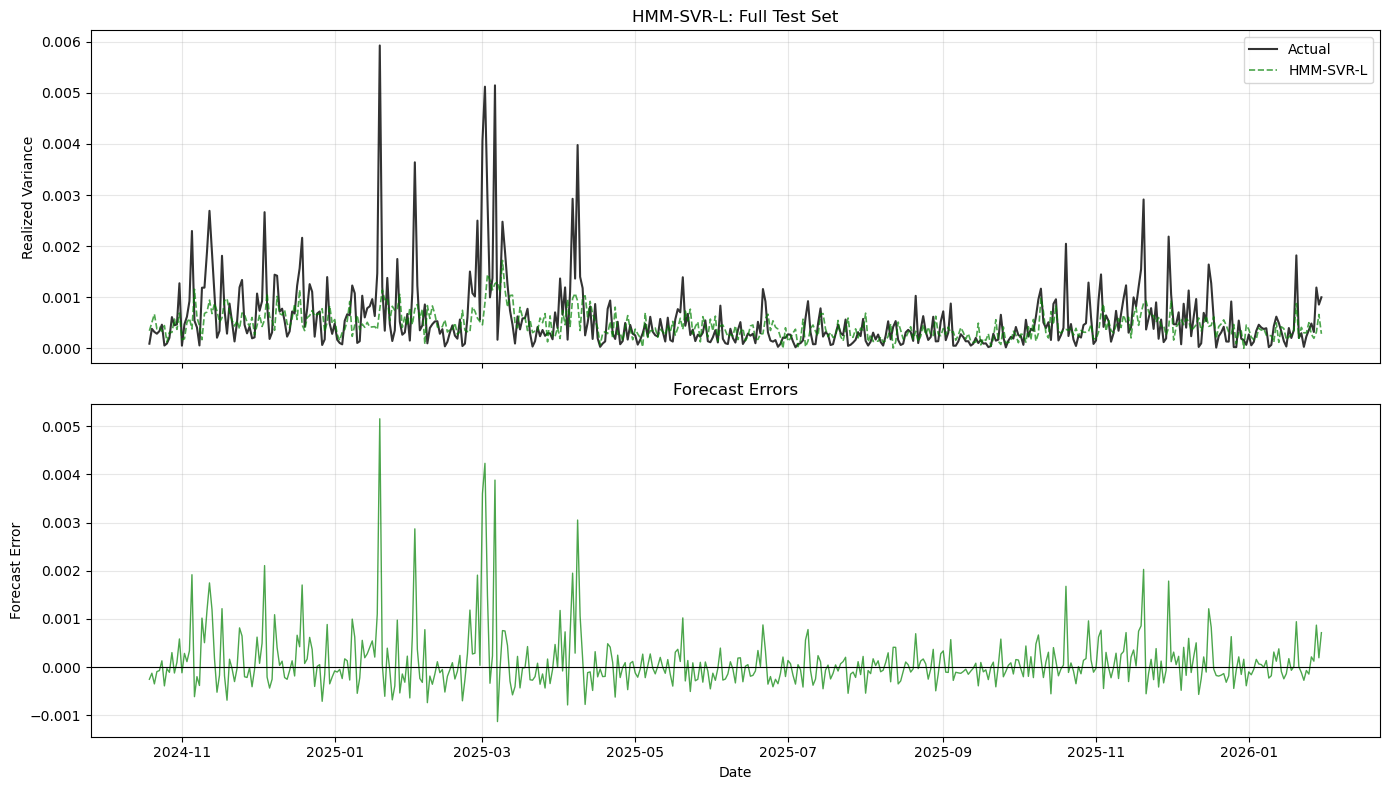

In [81]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

plot_n = len(test_actuals)
plot_dates = test_dates[-plot_n:]
plot_actuals = test_actuals[-plot_n:]
plot_forecasts = test_preds[-plot_n:]

# Panel 1: Actual vs Forecast
axes[0].plot(plot_dates, plot_actuals, label='Actual', color='black', linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label='HMM-SVR-L', color='green', linewidth=1.2, alpha=0.7, linestyle='--')
axes[0].set_ylabel('Realized Variance')
axes[0].set_title(f'HMM-SVR-L: Full Test Set')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Forecast Errors
errors = plot_actuals - plot_forecasts
axes[1].plot(plot_dates, errors, color='green', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].set_title('Forecast Errors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

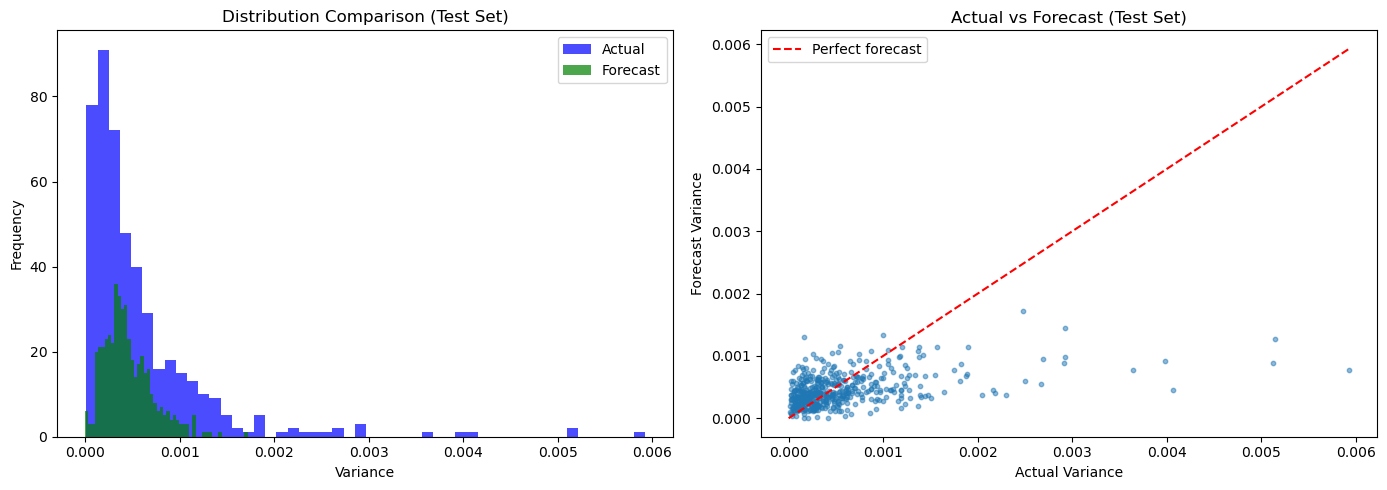


Forecast Statistics (Test Set):
  Mean forecast: 0.000453
  Mean actual:   0.000571
  Forecast std:  0.000258
  Actual std:    0.000689
  Forecasts > Actuals: 52.2%


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(test_actuals, bins=50, alpha=0.7, label='Actual', color='blue')
axes[0].hist(test_preds, bins=50, alpha=0.7, label='Forecast', color='green')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution Comparison (Test Set)')
axes[0].legend()

# Actual vs Forecast scatter
axes[1].scatter(test_actuals, test_preds, alpha=0.5, s=10)
axes[1].plot([0, test_actuals.max()], [0, test_actuals.max()], 'r--', label='Perfect forecast')
axes[1].set_xlabel('Actual Variance')
axes[1].set_ylabel('Forecast Variance')
axes[1].set_title('Actual vs Forecast (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {test_preds.mean():.6f}")
print(f"  Mean actual:   {test_actuals.mean():.6f}")
print(f"  Forecast std:  {test_preds.std():.6f}")
print(f"  Actual std:    {test_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(test_preds > test_actuals).mean()*100:.1f}%")